<h1 style="text-align:center; color:#2E86C1;">
🏡 House Price Prediction Project
</h1>


<p align="center">
  <b>End-to-End Machine Learning Project</b><br>
  Data Preprocessing • Feature Engineering • Model Tuning
</p>

## 📌 Machine Learning Project Workflow

1. 🔍 **Look at the Big Picture**  
2. 📥 **Get the Data**  
3. 📊 **Explore & Visualize the Data to Gain Insights**  
4. 🧹 **Prepare the Data for Machine Learning Algorithms**  
5. 🤖 **Select a Model and Train It**  
6. ⚙️ **Fine-Tune Your Model**  
7. 📢 **Present Your Solution**  
8. 🚀 **Launch, Monitor, and Maintain Your System**

## 🔄 What is a Data Pipeline?

A **data pipeline** is a sequence of steps where data flows from one stage to another,  
and each step processes or transforms the data.


### 💻 Real-Life Example: YouTube Recommendation System

When you watch videos, the system works like this:

1. 📥 **Data Collection** → Collects watch history, likes, searches  
2. 🧹 **Data Cleaning** → Removes errors or incomplete data  
3. ⚙️ **Feature Engineering** → Creates signals (e.g., "likes tech videos")  
4. 🤖 **Model Prediction** → Predicts what you may like  
5. 📺 **Recommendation Display** → Shows videos on homepage  

---

### ⚠️ Why Pipelines Are Robust

Even if the prediction system crashes, the platform can still show recommendations using previously saved results.

👉 This makes **data pipelines reliable and fault-tolerant**.

## 📥 Get the Data

In this step, we download and load the housing dataset for our project.

### 📌 What this code does:
- Downloads the dataset from an online source (if not already available)
- Extracts the compressed `.tgz` file
- Loads the dataset into a Pandas DataFrame

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

## 🔍 Take a Quick Look at the Data Structure

- Preview the dataset  
- Understand feature names and types  
- Check number of rows and columns  
- Identify missing or unusual values  

In [2]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


🔍 Data Structure Overview

- 📊 20,640 entries  
- 🧾 10 total features  
- 🔢 9 numerical features  
- 🔤 1 categorical feature (`ocean_proximity`)  
- ⚠️ Missing values in `total_bedrooms`  
- ✅ All other features are complete  
- 💾 Memory usage: ~1.6 MB  

#### Categorical feature (`ocean_proximity`) 

In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 📊 Visualizing Data with Histograms

- 📊 Histograms help understand data distribution  
- 📈 Show number of instances (y-axis) vs value ranges (x-axis)  
- 🔍 Useful for quickly understanding **numerical features**  
- ⚙️ Can plot one feature at a time  
- 🚀 Can generate histograms for all numerical features at once  
- 🧠 Helps identify skewness, outliers, and patterns  

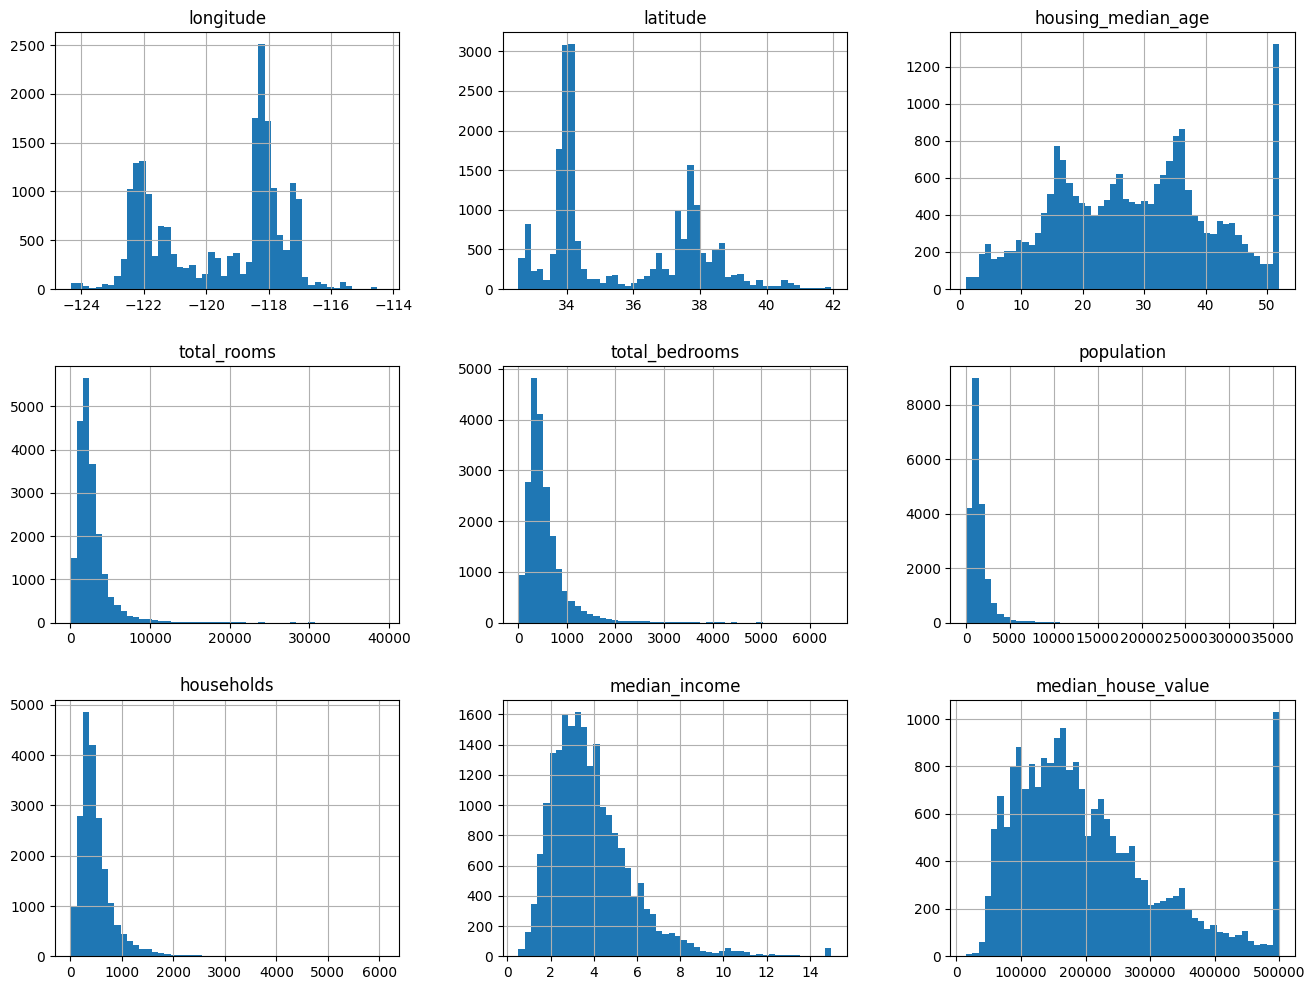

In [6]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(16, 12))
plt.show()

## 🚂 Train-Test Split

- 🔄 Splitting dataset into **training** and **testing** sets is essential  
- 🎯 Training set → used to train models  
- 🧪 Test set → used to evaluate model performance  

- ⚠️ Simple random split can produce **different test sets** on each run  
- ✅ Solutions to maintain consistency:
  - **Option-1:** Save the test set once and reuse it  
  - **Option-2** Set a fixed random seed (e.g., `np.random.seed(42)`)  </br>
However, both these solutions will break the next time you fetch an updated dataset.
- 💡 Best practice for stable splits:
  - Use a unique, immutable identifier for each instance  
  - Compute a hash of the identifier  
  - Include in test set if hash ≤ desired test ratio (e.g., 20%)  
  - Ensures test set stays consistent even after dataset updates  

- 🚀 This prevents leakage of new instances into the training set and keeps evaluation reliable

### 🔒 Stable Train-Test Split Using ID Hashing

- 🎯 Ensures a consistent test set across multiple runs  
- 🆔 Uses a **unique identifier** for each instance (e.g., index or ID column)  
- 🔢 Computes a hash (CRC32) of each identifier  
- 🧪 Instance is in test set if hash ≤ desired test ratio (e.g., 20%)  
- ✅ Prevents overlap between training and test sets after dataset updates  
- 🚀 Provides a **robust and reproducible** way to split data  

In [7]:
from zlib import crc32
import numpy as np

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32
def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [8]:
housing_with_id = housing.reset_index()  # adds an `index` column
housing_with_id

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [9]:
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [10]:
train_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
6,6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20635,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [11]:
test_set

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
16,16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...,...
20615,20615,-121.54,39.08,23.0,1076.0,216.0,724.0,197.0,2.3598,57500.0,INLAND
20617,20617,-121.53,39.06,20.0,561.0,109.0,308.0,114.0,3.3021,70800.0,INLAND
20622,20622,-121.44,39.00,20.0,755.0,147.0,457.0,157.0,2.4167,67000.0,INLAND
20626,20626,-121.43,39.18,36.0,1124.0,184.0,504.0,171.0,2.1667,93800.0,INLAND


## **📊 Stratified Sampling**

- 🎯 Ensures that the test set is **representative of important attributes**  
- 🔹 Population is divided into **homogeneous subgroups** called **strata**  
- 🔹 Samples are taken from each stratum in **proportion to its size**  
- 🏠 Example: Median income is an important predictor of housing prices  
- 🔢 Continuous attributes (like median income) can be **binned into categories**  
  - Category 1 → 0 to 1.5 ($0–$15,000)  
  - Category 2 → 1.5 to 3 ($15,000–$30,000)  
  - … up to Category 5  
- ✅ Helps maintain proper representation of all income levels in train/test sets  
- ⚖️ Prevents bias that could occur if some strata are underrepresented  

#### **STEP-1:** Create binned categories for a specific speacial attribute(median income)

In [12]:
housing["income_cat"] = pd.cut(housing["median_income"],bins=[0., 1.5, 3.0, 4.5, 6., np.inf],labels=[1, 2, 3, 4, 5])
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


In [13]:
housing["income_cat"].value_counts().sort_index()

income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64

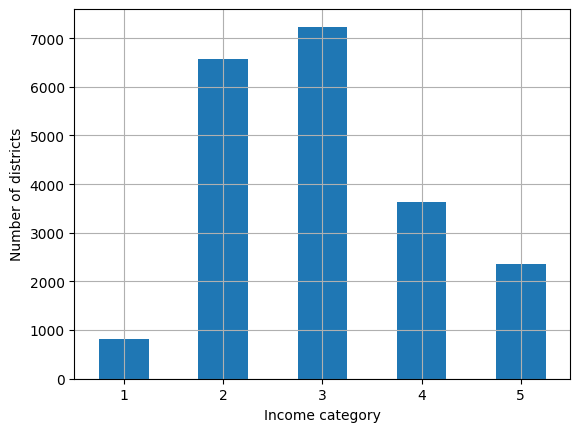

In [14]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

#### **STEP-2: Option-1:** Stratified Sampling **(n number splits)** with Scikit-Learn

- 🚀 Ready to perform stratified sampling using income categories  
- 📦 Scikit-Learn provides splitter classes in `sklearn.model_selection`  
- 🔄 These splitters implement different strategies for train-test splitting  

- 🔧 Each splitter has a `split()` method  
- 📌 `split()` returns **indices**, not the actual data  
- 🔍 These indices are used to create training and test sets  

- 🔁 Multiple splits can be generated from the same dataset  
- 📊 Useful for better performance estimation  
- 🧠 Forms the foundation for **cross-validation techniques**  

In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

strat_splits = []

for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [16]:
strat_train_set, strat_test_set = strat_splits[1]

In [17]:
strat_train_set.shape

(16512, 11)

#### **STEP-2: Option-2:** Stratified Sampling **(single split)** with Scikit-Learn

- 🚀 Easy way to perform stratified sampling using Scikit-Learn  
- ⚙️ Use `train_test_split()` with the **`stratify`** argument  

In [18]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)


#### **STEP-3:** 🎯 Ensures train and test sets have **same proportion of income categories** 

- 🔍 After splitting:
  - Check proportions using `value_counts() / len(dataset)`  
  - 📈 Test set proportions ≈ Training set proportions 

In [19]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [20]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

#### ✅ Result:
- Both train and test sets maintain **similar distribution**  
- Reduces sampling bias 

#### 🧹 Removing Temporary Feature

- 🧪 `income_cat` was created only for stratified sampling  
- 🎯 It is no longer needed after splitting the data  

- 🗑️ Remove `income_cat` from both:
  - Training set  
  - Test set  

- 🔄 Restores dataset to its original structure  
- ✅ Prevents unnecessary or misleading features in model training  

In [21]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [22]:
strat_test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
3905,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360,397700.0,<1H OCEAN
16821,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354,202900.0,<1H OCEAN
2900,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968,310000.0,NEAR OCEAN
7193,-122.48,37.74,52.0,2166.0,423.0,1072.0,370.0,4.1310,314300.0,NEAR OCEAN
13928,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,187500.0,NEAR BAY


In [23]:
strat_test_set.shape

(4128, 10)

## 🗺️ Visualizing Geographical Data

- 📍 Dataset includes geographical features → `longitude` and `latitude`  
- 📊 **Scatter plot** helps visualize spatial distribution of districts      

#### 👀 Initial plot:
- Shows overall map structure  
- Hard to identify clear patterns

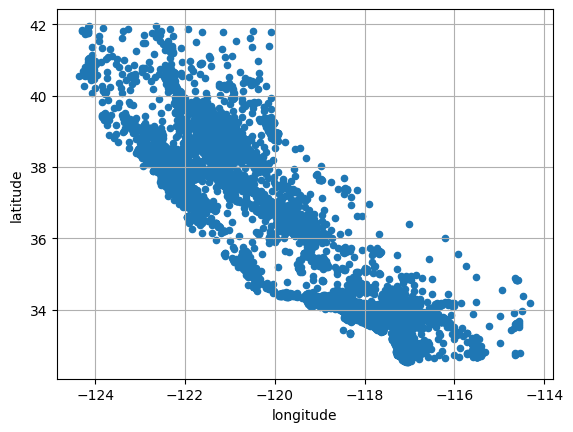

In [24]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

#### 🎯 Using transparency (`alpha=0.2`):
- Reveals **high-density regions**  
- Makes patterns more visible 

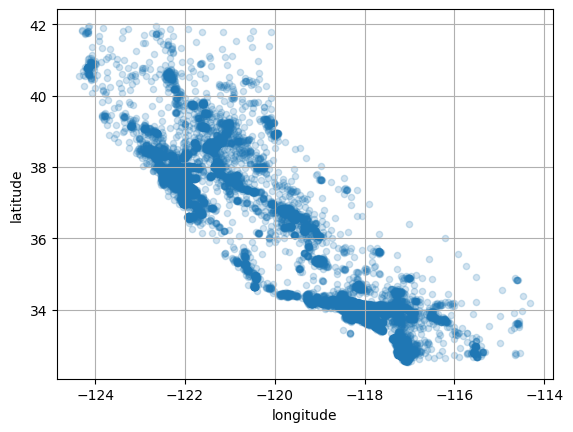

In [25]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, 
alpha=0.2)
plt.show()

#### 🌆 High-density areas observed:
- Bay Area  
- Los Angeles  
- San Diego  
- Central Valley (Sacramento, Fresno) 

## 💰 Visualizing Housing Prices by enhanced scatter plot with additional features:
- 📏 Circle size (`s`) → represents **population**  
- 🎨 Color (`c`) → represents **housing prices**  

- 🌈 Color map (`jet`):
  - 🔵 Blue → low prices  
  - 🔴 Red → high prices 

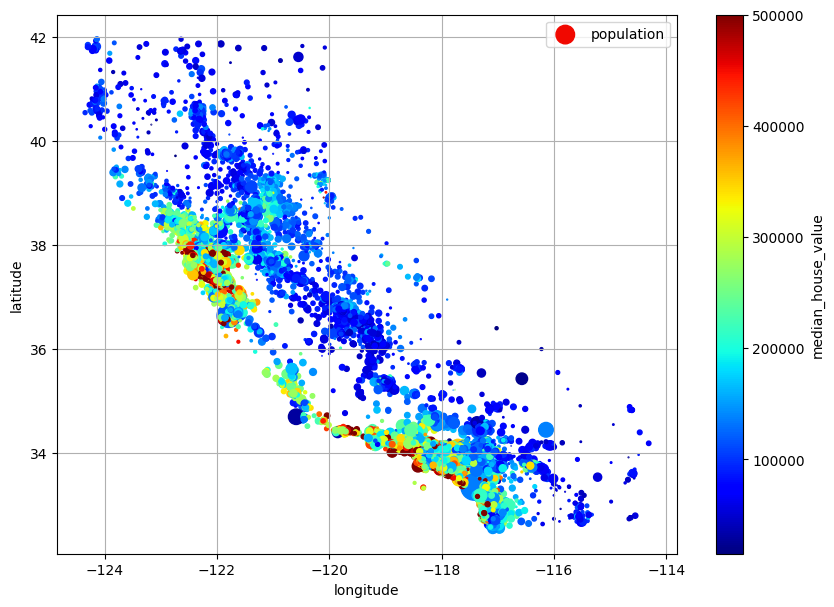

In [26]:
housing.plot(kind="scatter",
             x="longitude", 
             y="latitude", 
             grid=True,
             s=housing["population"] / 100,
             label="population",
             c="median_house_value", 
             cmap="jet", 
             colorbar=True,
             legend=True, 
             sharex=False, 
             figsize=(10, 7))
plt.show()

- 🔍 Key observations:
  - Housing prices strongly depend on **location**  
  - Higher prices near **coastal areas**  
  - Relationship with **population density**  

- 🧠 Insights:
  - Location is a key factor in price prediction  
  - Clustering algorithms can help identify important regions  
  - `ocean_proximity` feature may also be useful (not always consistent)

## 🔗 Looking for Correlations between **numerical attributes**

- 📊 Measure relationship between pairs of attributes  
- ⚙️ Use correlation matrix to analyze dependencies  

- 🔍 Helps identify:
  - Strong positive correlations 📈  
  - Strong negative correlations 📉  
  - Weak or no relationships  

- 🎯 Useful for:
  - Selecting important features  
  - Understanding data patterns  
  - Improving model performance  

- 🧠 Focus on attributes highly correlated with the target variable  

In [27]:
corr_matrix = housing.select_dtypes('float').corr()

In [28]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

### 🔍 Scatter Matrix for Correlation

- 📊 Another way to analyze correlations → use scatter matrix  
- 🔄 Plots every numerical attribute against every other attribute  

- ⚠️ Problem:
  - Too many attributes → too many plots (e.g., 11 → 121 plots)  
  - Difficult to visualize and interpret  

- 🎯 Solution:
  - Select a few important attributes  
  - **Focus on features highly correlated with target variable**

- 🔧 Use correlation analysis **(`corr()`)** to choose relevant attributes  

- 🧠 Benefit:
  - Clear visualization of relationships  
  - Easier to detect patterns and trends  

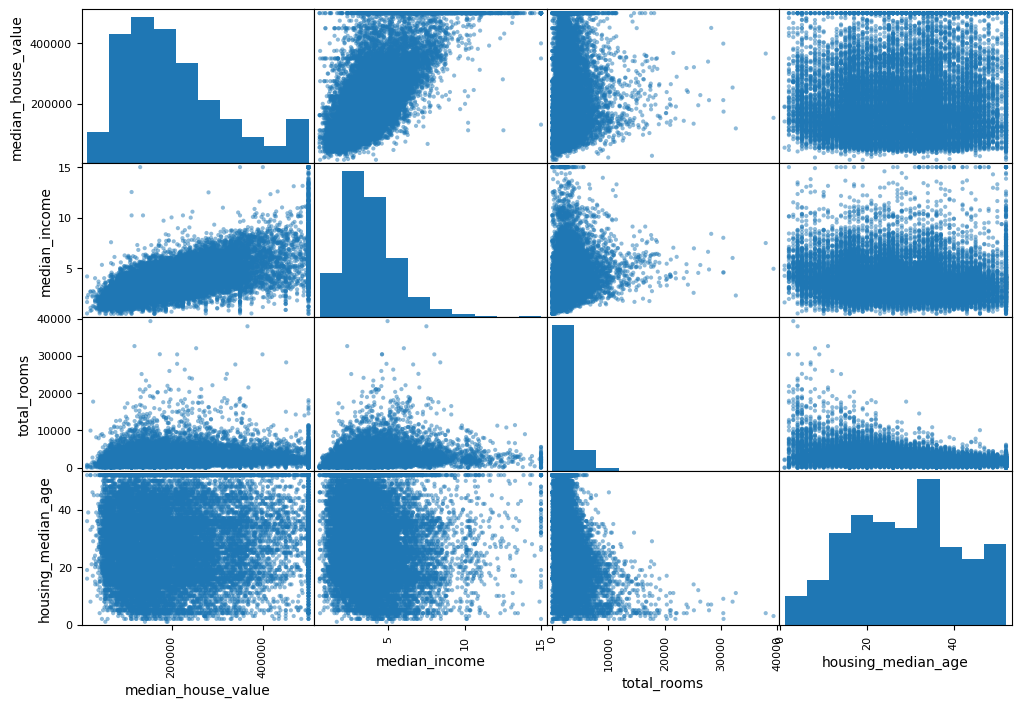

In [29]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms","housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

#### 🔥 Heatmap (Correlation Visualization)

- 📊 Visual representation of correlation matrix  
- 🎨 Uses colors to show strength of relationships  

- 🌈 Color meaning:
  - 🔵 Cool colors → low or negative correlation  
  - 🔴 Warm colors → high positive correlation  

- 🔍 Helps to:
  - Quickly identify strong relationships  
  - Detect multicollinearity between features  
  - Spot important features for prediction  

- 🎯 Focus:
  - Look for features highly correlated with target variable  
  - Avoid features that are highly correlated with each other  

- 🧠 Advantage:
  - Easier and faster than reading numerical correlation tables 

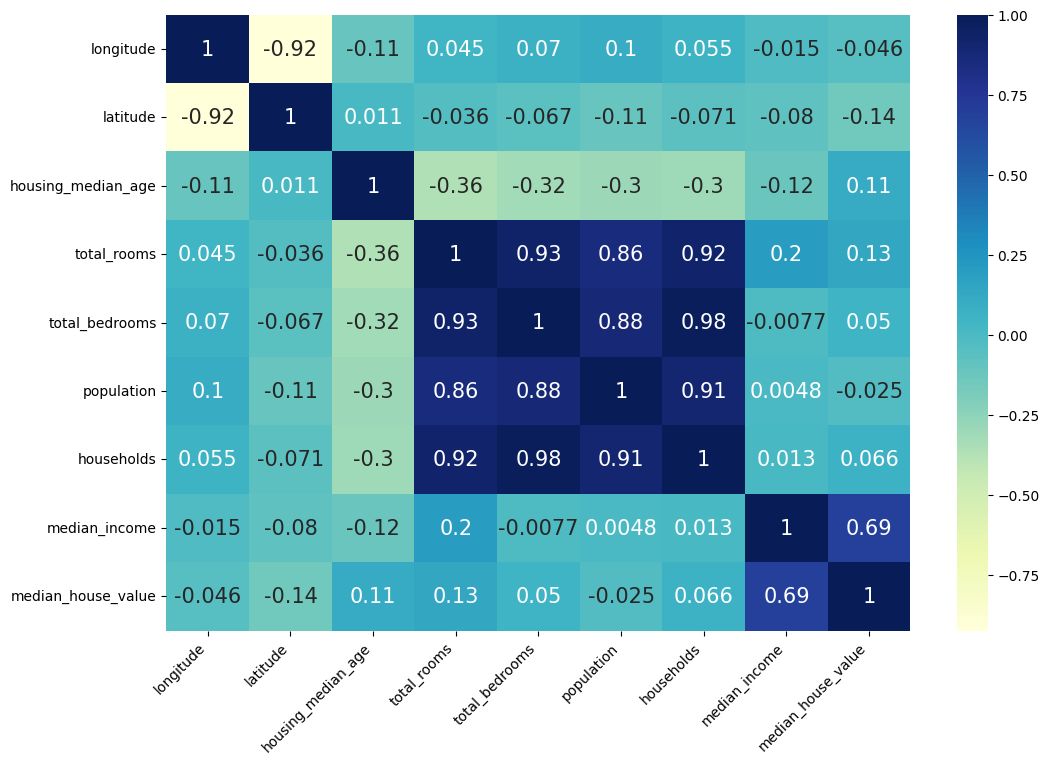

In [30]:
import seaborn as sns 

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
    cmap="YlGnBu",
    annot=True,
    annot_kws={"size":15})

plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.show()

## 🧪 Experimenting with **Attribute Combinations**

- 🔍 Combine existing features to create more meaningful attributes  
- 🏠 Raw features alone may not provide enough insight  

- 🎯 Goal:
  - Improve feature quality  
  - Capture real-world relationships  
#### 🧠 Key Insight

- 📊 Ratios and combinations are often more informative than raw values  
- 🚀 Better features → better model performance  

In [31]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

#### Then you look at the correlation matrix again:

In [32]:
corr_matrix = housing.select_dtypes('float').corr()

In [33]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
rooms_per_house       0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
people_per_house     -0.023737
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedrooms_ratio       -0.255880
Name: median_house_value, dtype: float64

#### 📈 Insights from New Features

- 🔗 `bedrooms_ratio` shows stronger correlation with house prices than the total number of rooms or bedrooms
- 🛏️ Lower bedroom/room ratio → higher house value  

- 🏠 `rooms_per_house` is more informative than total rooms  
- 📊 Larger houses (more rooms per household) → higher prices 

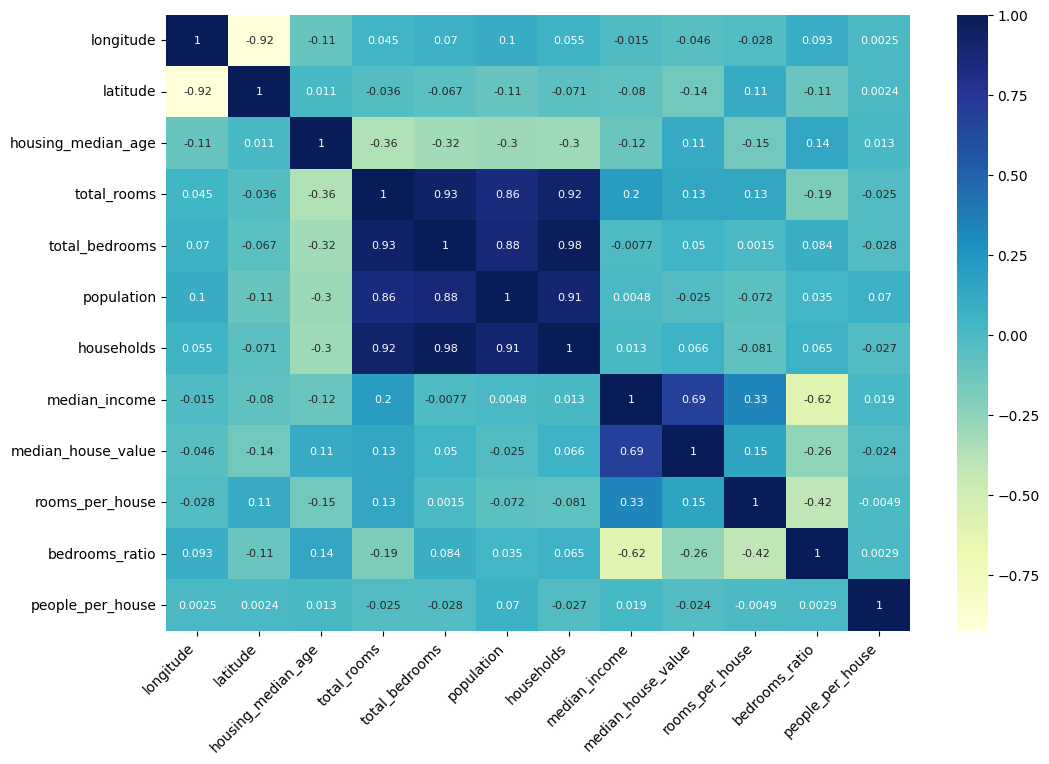

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
    cmap="YlGnBu",
    annot=True,
    annot_kws={"size":8})

plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.show()

## 🧼 Prepare the Data for Machine Learning Algorithms

- **step-1:** 🧹 Clean the Data  
- **step-2:** 🔤 Handle Text and Categorical Attributes  
- **step-3:** 📏 Feature Scaling and Transformation  
- **step-4:** 🛠️ Create Custom Transformers  
- **step-5:** 🔄 Build Transformation Pipelines  

#### 🧹 Revert to Clean Training Set

- 🔄 create a clean copy of main data
- 📌 Separate predictors (features) and labels (target variable)  

- 🎯 Why this is important:
  - **Predictors and target may need different transformations**
  - Ensures clean and organized preprocessing pipeline  

In [35]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

### **Step-1:** 🧼 Clean the Data

- ⚠️ Most ML algorithms cannot handle missing values  
- 📊 Example: `total_bedrooms` contains missing data  

#### ❗ Ways to Handle Missing Data

- 🗑️ Option 1: Remove rows with missing values (`dropna()`)
- 🚫 Option 2: Remove the entire attribute  (`drop()`)
- 🔧 Option 3: Fill missing values (imputation)  [Note:Decide to go for option 3 since it is the least destructive]


#### 🧪 Imputation Methods

- 🔹 Replace with statistical values:
  - Mean  
  - Median  
  - Zero (less recommended)  

- 🎯 In this case: median is preferred (least data loss) 

In [36]:
median = housing["total_bedrooms"].median()

housing["total_bedrooms"].fillna(median, inplace=True)

C:\Users\Fayshal01\AppData\Local\Temp\ipykernel_23856\1042364730.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


In [37]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


#### ⚙️ Scikit-Learn Approach for handling missing values using **`SimpleImputer`**
- 🔧 `SimpleImputer` is used to handle missing values in datasets  
- 📊 It replaces missing values using a chosen strategy such as **median, mean, most frequent, constant**
<br>

- 📌 Advantages:
  - Learns median from training data  
  - Can be reused on Training data, Validation data, Test data, New unseen data
  - Ensures consistent preprocessing  
#### 🧪 How It Works

- 🏗️ Create an imputer with a strategy (e.g., `"median"`)  
- 🔢 Select only numerical attributes (exclude text features)  
- 📊 Fit the imputer on training data  
  - Computes statistics for each feature  
- 🔄 Transform data  
  - Replaces missing values with learned statistics 

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [39]:
housing_num = housing.select_dtypes(include=[np.number])

In [40]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [41]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [42]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [43]:
X = imputer.transform(housing_num)

In [44]:
X

array([[-1.2242e+02,  3.7800e+01,  5.2000e+01, ...,  1.5760e+03,
         1.0340e+03,  2.0987e+00],
       [-1.1838e+02,  3.4140e+01,  4.0000e+01, ...,  6.6600e+02,
         3.5700e+02,  6.0876e+00],
       [-1.2198e+02,  3.8360e+01,  3.3000e+01, ...,  5.6200e+02,
         2.0300e+02,  2.4330e+00],
       ...,
       [-1.1706e+02,  3.2590e+01,  1.3000e+01, ...,  2.8140e+03,
         7.6000e+02,  4.0616e+00],
       [-1.1840e+02,  3.4060e+01,  3.7000e+01, ...,  1.7250e+03,
         8.3800e+02,  4.1455e+00],
       [-1.2241e+02,  3.7660e+01,  4.4000e+01, ...,  6.8200e+02,
         2.1200e+02,  3.2833e+00]], shape=(16512, 8))

##### 🔄 Transformer Output Handling

- ⚠️ Scikit-Learn transformers return NumPy arrays  
- 📉 Output does NOT include:
  - Column names  
  - Index  

##### 📊 Problem

- 🧾 Original data (Pandas DataFrame) has labels  
- 🔄 After transformation → labels are lost  

##### ✅ Solution

- 🔁 Convert NumPy array back to Pandas DataFrame  
- 📌 Restore:
  - Column names  
  - Index  

In [45]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [46]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


In [47]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN


### **Step-2:** 🔤 Handle Text and Categorical Attributes
- 📊 Dataset may contain non-numerical (text) features  
- 🌊 Example: `ocean_proximity` attribute   

#### ⚠️ Problem

- 🤖 Most machine learning algorithms require numerical input  
- ❌ Cannot directly use text categories  

### ✅ Solution

- 🔢 Convert categorical values into numerical format  
- 🎯 This process is called **encoding**  


In [ ]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


In [49]:
housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

### 🔢 Ordinal Encoding

- 🛠️ `OrdinalEncoder` converts categories into numbers  
- 📌 Example:
  - `NEAR BAY` → 0  
  - `INLAND` → 1  
  - `NEAR OCEAN` → 2  

#### 🔢 Use `OrdinalEncoder`
- 📌 Categories have natural order  
- 🧾 Example:
  - Low  
  - Medium  
  - High 

In [50]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [51]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

get the list of categories using the categories_ instance variable

In [52]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

##### ⚠️ Problem with Ordinal Encoding

- 🤖 ML models may assume:
  - Nearby numbers are more similar  
  - Larger numbers imply higher importance  

- ❌ This assumption is incorrect for unordered categories  
- 🌊 Example:
  - `0` and `4` may be more similar than `0` and `1`  
  - This may be fine in some cases (e.g., for ordered categories such as “bad”, “average”, “good”, and “excellent”), but it is obviously not the case for the ocean_proximity column (for example, categories 0 and 4 are clearly more similar than categories 0 and 1).


### 🎯 One-Hot Encoding

- 🔄 Creates one binary feature per category  
- 🔥 Only one category becomes `1` (hot)  
- ❄️ All others become `0` (cold)  

- 📌 Example:
  - `<1H OCEAN` → `[1,0,0,0]`  
  - `INLAND` → `[0,1,0,0]`  

#### 🔥 Use `OneHotEncoder`
- 📌 Categories have no order  
- 🧾 Example:
  - Red  
  - Blue  
  - Green  

In [62]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

#### 💾 Sparse Matrix

- 📊 One-hot encoding creates many zeros  
- 💡 Sparse matrix stores only:
  - Non-zero values  
  - Their positions  

- 🚀 Benefits:
  - Saves memory  
  - Faster computation  

- 🔄 Convert to dense array using:
  - `toarray()`  

- ⚙️ Or use:
  - `sparse=False` in `OneHotEncoder`  

In [63]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [64]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))